In [ ]:
# Cell 1 - Mount Drive and load merged raw data
from google.colab import drive

try:
    drive.mount('/content/drive')
    print('✅ Drive mounted!')
except:
    print('✅ Drive already mounted!')

import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/PhishingDetector/data/raw/merged_raw.csv')

print(f'✅ Data loaded!')
print(f'📊 Shape: {df.shape}')
print(f'📋 Columns: {df.columns.tolist()}')
print(f'📊 Label distribution:')
print(df['label'].value_counts())

Mounted at /content/drive
✅ Drive mounted!
✅ Data loaded!
📊 Shape: (79627, 2)
📋 Columns: ['text', 'label']
📊 Label distribution:
label
1    42433
0    37194
Name: count, dtype: int64


In [ ]:
# Cell 2 - Install and import libraries
!pip install nltk -q

import pandas as pd
import numpy as np
import re
import os
import nltk
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

print('✅ All libraries ready!')

✅ All libraries ready!


In [ ]:
# Cell 3 - Check data quality
print('🔍 Missing values:')
print(df.isnull().sum())

print(f'\n🔍 Duplicate rows: {df.duplicated().sum()}')

print(f'\n🔍 Sample phishing email:')
print(df[df['label']==1]['text'].iloc[0][:300])

print(f'\n🔍 Sample legit email:')
print(df[df['label']==0]['text'].iloc[0][:300])

🔍 Missing values:
text     0
label    0
dtype: int64

🔍 Duplicate rows: 0

🔍 Sample phishing email:
Never agree to be a loser Buck up, your troubles caused by small dimension will soon be over!
Become a lover no woman will be able to resist!
http://whitedone.com/


come. Even as Nazi tanks were rolling down the streets, the dreamersphilosopher or a journalist. He was still not sure.I do the same.

🔍 Sample legit email:
Re: svn commit: r619753 - in /spamassassin/trunk: lib/Mail/SpamAssassin/PerMsgStatus.pm lib/Mail/SpamAssassin/Util/RegistrarBoundaries.pm t/uri_text.t Would anyone object to removing .so from this list?  The .so TLD is  
basically dead and we've found that lots of bogus domains like lib*.so  
are be


In [ ]:
# Cell 4 - Text cleaning function
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'<[^>]+>', ' ', text)        # remove HTML
    text = re.sub(r'http\S+|www\S+', ' ', text) # remove URLs
    text = re.sub(r'\S+@\S+', ' ', text)         # remove emails
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)     # remove special chars
    text = re.sub(r'\s+', ' ', text).strip()      # remove extra spaces
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words
             if w not in stop_words and len(w) > 2]
    return ' '.join(words)

# Test on real samples
print('🔍 Test on phishing email:')
sample1 = df[df['label']==1]['text'].iloc[0]
print('Before:', sample1[:150])
print('After:', clean_text(sample1)[:150])

print('\n🔍 Test on legit email:')
sample2 = df[df['label']==0]['text'].iloc[0]
print('Before:', sample2[:150])
print('After:', clean_text(sample2)[:150])

🔍 Test on phishing email:
Before: Never agree to be a loser Buck up, your troubles caused by small dimension will soon be over!
Become a lover no woman will be able to resist!
http://w
After: never agree loser buck trouble caused small dimension soon become lover woman able resist come even nazi tank rolling street dreamersphilosopher journ

🔍 Test on legit email:
Before: Re: svn commit: r619753 - in /spamassassin/trunk: lib/Mail/SpamAssassin/PerMsgStatus.pm lib/Mail/SpamAssassin/Util/RegistrarBoundaries.pm t/uri_text.t
After: svn commit spamassassin trunk lib mail spamassassin permsgstatus lib mail spamassassin util registrarboundaries uri text would anyone object removing 


In [ ]:
# Cell 5 - Apply cleaning to entire dataset
print('Cleaning all emails... takes 2-3 minutes...')

df['cleaned_text'] = df['text'].apply(clean_text)

# Remove empty rows after cleaning
before = len(df)
df = df[df['cleaned_text'].str.len() > 10].reset_index(drop=True)
after = len(df)

print(f'✅ Cleaning done!')
print(f'📊 Removed {before - after} empty rows')
print(f'📊 Final shape: {df.shape}')

Cleaning all emails... takes 2-3 minutes...
✅ Cleaning done!
📊 Removed 77 empty rows
📊 Final shape: (79550, 3)


In [ ]:
# Cell 6 - Extract features from original text
print('Extracting features...')

# URL count
df['url_count'] = df['text'].apply(
    lambda x: len(re.findall(r'http\S+|www\S+', str(x)))
)

# Urgency keywords
urgency_words = ['urgent', 'verify', 'click', 'suspended', 'account',
                 'password', 'confirm', 'update', 'limited', 'expire',
                 'warning', 'immediately', 'alert', 'security', 'bank']

df['urgency_count'] = df['text'].apply(
    lambda x: sum(word in str(x).lower() for word in urgency_words)
)

# Email length and word count
df['email_length'] = df['cleaned_text'].apply(len)
df['word_count'] = df['cleaned_text'].apply(lambda x: len(x.split()))

print('✅ Features extracted!')
print(df[['url_count', 'urgency_count', 'email_length', 'word_count']].describe().round(2))

print(f'\n🔍 Emails with URLs: {(df["url_count"] > 0).sum()}')
print(f'🔍 Emails with urgency words: {(df["urgency_count"] > 0).sum()}')

Extracting features...
✅ Features extracted!
       url_count  urgency_count  email_length  word_count
count   79550.00       79550.00      79550.00    79550.00
mean        2.01           0.66        978.89      135.84
std        13.48           1.14      12574.88     1517.72
min         0.00           0.00         11.00        2.00
25%         0.00           0.00        191.00       28.00
50%         0.00           0.00        423.00       63.00
75%         1.00           1.00       1044.00      152.00
max      3133.00          15.00    3471660.00   417249.00

🔍 Emails with URLs: 32878
🔍 Emails with urgency words: 28652


In [ ]:
# Cell 7 - Remove extreme outliers
before = len(df)

df = df[df['word_count'] <= 10000].reset_index(drop=True)

after = len(df)
print(f'✅ Removed {before - after} extreme outlier emails')
print(f'📊 Final shape: {df.shape}')
print(f'\n📊 Updated word count stats:')
print(df['word_count'].describe().round(2))

✅ Removed 13 extreme outlier emails
📊 Final shape: (79537, 7)

📊 Updated word count stats:
count    79537.00
mean       128.43
std        288.75
min          2.00
25%         28.00
50%         63.00
75%        152.00
max       9788.00
Name: word_count, dtype: float64


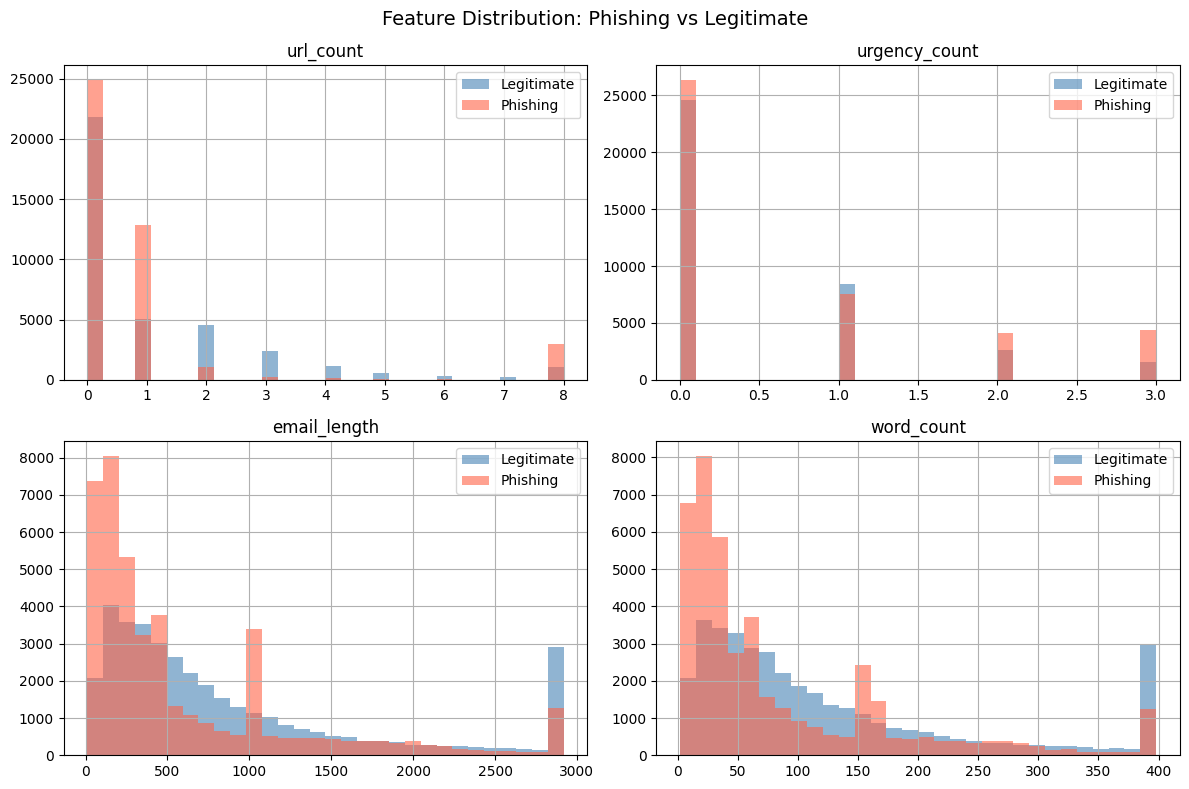

✅ Plot saved!


In [ ]:
# Cell 8 - Visualize features by class
import matplotlib.pyplot as plt
import os

os.makedirs('/content/drive/MyDrive/PhishingDetector/plots', exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

features = ['url_count', 'urgency_count', 'email_length', 'word_count']

for i, feature in enumerate(features):
    ax = axes[i//2][i%2]
    max_val = df[feature].quantile(0.95)
    df[df['label']==0][feature].clip(upper=max_val).hist(
        bins=30, alpha=0.6, color='steelblue', label='Legitimate', ax=ax)
    df[df['label']==1][feature].clip(upper=max_val).hist(
        bins=30, alpha=0.6, color='tomato', label='Phishing', ax=ax)
    ax.set_title(feature)
    ax.legend()

plt.suptitle('Feature Distribution: Phishing vs Legitimate', fontsize=14)
plt.tight_layout()

save_path = '/content/drive/MyDrive/PhishingDetector/plots/feature_distribution.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()

if os.path.exists(save_path):
    print('✅ Plot saved!')

In [ ]:
# Cell 9 - Split data into train and test sets
from sklearn.model_selection import train_test_split

X = df['cleaned_text']
y = df['label']
extra_features = df[['url_count', 'urgency_count', 'email_length', 'word_count']]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
extra_train, extra_test = train_test_split(
    extra_features, test_size=0.2, random_state=42, stratify=y
)

print(f'✅ Split done!')
print(f'📊 Train: {len(X_train)} | Test: {len(X_test)}')
print(f'📊 Train phishing %: {y_train.mean()*100:.1f}%')
print(f'📊 Test phishing %: {y_test.mean()*100:.1f}%')

✅ Split done!
📊 Train: 63629 | Test: 15908
📊 Train phishing %: 53.3%
📊 Test phishing %: 53.3%


In [ ]:
# Cell 10 - Save all processed data to Drive
import os

base = '/content/drive/MyDrive/PhishingDetector/data/processed'
os.makedirs(base, exist_ok=True)

# Save full processed dataframe
df.to_csv(f'{base}/phishing_processed.csv', index=False)

# Save splits
X_train.to_csv(f'{base}/X_train.csv', index=False, header=True)
X_test.to_csv(f'{base}/X_test.csv', index=False, header=True)
y_train.to_csv(f'{base}/y_train.csv', index=False, header=True)
y_test.to_csv(f'{base}/y_test.csv', index=False, header=True)
extra_train.to_csv(f'{base}/extra_train.csv', index=False)
extra_test.to_csv(f'{base}/extra_test.csv', index=False)

# Verify
print('✅ All files saved!')
for f in os.listdir(base):
    size = round(os.path.getsize(f'{base}/{f}') / (1024*1024), 2)
    print(f'   {f} — {size} MB')

✅ All files saved!
   phishing_processed.csv — 197.57 MB
   X_train.csv — 55.83 MB
   X_test.csv — 13.92 MB
   y_train.csv — 0.12 MB
   y_test.csv — 0.03 MB
   extra_train.csv — 0.7 MB
   extra_test.csv — 0.17 MB
